# P0 · Containers and shared references

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys
print("Python", sys.version.split()[0])
print("Self-contained notebook. Run top to bottom; no repository clone or API key.")


Python 3.12.3
Self-contained notebook. Run top to bottom; no repository clone or API key.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P0.3 · Containers and shared references

Assignment shares an object. A shallow copy creates a new outer container while nested objects may remain shared.

**Prerequisites:** Text, positions, and slices

**Predict:** After b=a, does b[0]=9 also affect a?

**Mental model:** Two variable names can refer to the same list. A name is a way to reach an object; it is not a box that automatically receives a fresh copy.

<a id="python-names"></a>

<a data-compat-cell="p0-names-lists-and-dicts"></a>

### Why this operation exists

Two variable names can refer to the same list. A name is a way to reach an object; it is not a box that automatically receives a fresh copy.

Imagine drawing arrows from both names to a single list. Editing through either arrow reaches the same stored elements.

Copying the outer list changes this picture, but nested lists introduce another layer of arrows. Their contents may still be shared.

This is useful when sharing is intentional and confusing when it is accidental. Predict the object relationships before predicting the printed values.

Later, tensor views and tied model weights will reuse this distinction between a new name, a new container and independent storage.

### Follow the values

The starting list contains 2, 0 and 1. In the first experiment, both names refer to that same object.

Assign 9 through b at position zero. Reading a now sees the changed value too. Switch to the copy experiment to keep a unchanged.

Make a shallow copy of a nested list. The outer containers are different objects, as the identity comparison confirms.

Append 3 to the first inner list through the copy. Both outer containers still refer to that inner list, so the original also displays the appended value.

A comprehension creates a fresh inner list on each iteration. Editing the first leaves the second alone. The diagram now has two independent inner objects.

In [3]:
FRAMES.clear()
change = 0
a = [2, 0, 1]
b = a.copy() if change else a
show("Before the change", {"a": a.copy(), "b": b.copy(), "same object": a is b})
b[0] = 9
show("After b[0] = 9", {"a": a.copy(), "b": b.copy()})
nested = [[1], [2]]
outer_copy = nested.copy()
show("New outer list", nested is outer_copy)
outer_copy[0].append(3)
show("Shared inner list", nested)
independent = [[0] for _ in range(2)]
independent[0].append(7)
show("Independent inner lists", independent)

Before the change: {"a": [2, 0, 1], "b": [2, 0, 1], "same object": true}
After b[0] = 9: {"a": [9, 0, 1], "b": [9, 0, 1]}
New outer list: false
Shared inner list: [[1, 3], [2]]
Independent inner lists: [[0, 7], [0]]


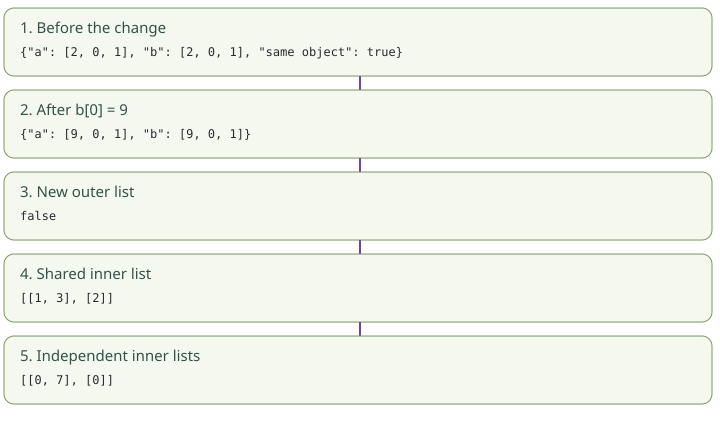

In [4]:
draw_trace()

### Read the implementation

Read the assignment that chooses either the same object or a shallow copy. The identity operator asks whether two names reach the same object.

Item assignment mutates an existing list. Reassigning the name b would instead redirect that name without editing the old list.

Copying a nested container only copies its outer layer. Inspect the inner references before assuming that all descendants are independent.

Append adds one object; extend adds the elements from another iterable. A tuple prevents replacing its own entries, although an entry can itself refer to a mutable list.

For independent inner lists, construct them separately in a comprehension. Avoid repeating a single mutable inner list when you intend separate state.

### Change one thing

**Copy the list before changing b**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [5]:
FRAMES.clear()
change = 1
a = [2, 0, 1]
b = a.copy() if change else a
show("Before the change", {"a": a.copy(), "b": b.copy(), "same object": a is b})
b[0] = 9
show("After b[0] = 9", {"a": a.copy(), "b": b.copy()})
nested = [[1], [2]]
outer_copy = nested.copy()
show("New outer list", nested is outer_copy)
outer_copy[0].append(3)
show("Shared inner list", nested)
independent = [[0] for _ in range(2)]
independent[0].append(7)
show("Independent inner lists", independent)

Before the change: {"a": [2, 0, 1], "b": [2, 0, 1], "same object": false}
After b[0] = 9: {"a": [2, 0, 1], "b": [9, 0, 1]}
New outer list: false
Shared inner list: [[1, 3], [2]]
Independent inner lists: [[0, 7], [0]]


### A useful distinction

Equal values do not prove separate storage. A shallow copy does not recursively copy nested objects.

### ✋ Your turn

Create two independent empty lists in answer, then append 7 only to the first.

In [6]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[7], []] and answer[0] is not answer[1], 'Equal values do not prove separate storage. A shallow copy does not recursively copy nested objects.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [7]:
#@title Show a solution { display-mode: "form" }
answer = [[] for _ in range(2)]
answer[0].append(7)

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[7], []] and answer[0] is not answer[1], 'Equal values do not prove separate storage. A shallow copy does not recursively copy nested objects.'
    print("✓ right:", answer)

✓ right: [[7], []]


### Reconnect to the transformer

Model weights can be shared deliberately. The token embedding and the readout may refer to the same learned tensor rather than two equal copies.

A tensor view can also share storage. Changing a view may affect the original, even when the two tensors have different shapes.

Python assignment, a tensor clone and detaching a tensor answer different questions. PyTorch will teach storage independence separately from gradient recording.

Training checkpoints need a preserved state, not an accidental reference to numbers that training continues to modify. That is why copying and serialization matter.

Next, use a different container: a dictionary that maps a character to its ID.

```python
best_state = copy.deepcopy(model.state_dict())
# Preserve a snapshot while training continues.
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** After b=a, does b[0]=9 also affect a?

<details><summary>Check your explanation</summary>

Yes; both names reach the same list. Equal values do not prove separate storage. A shallow copy does not recursively copy nested objects.

</details>